# Bayesian Network Structure Learning — POC Experiment

Compares **Hill Climbing** (pgmpy) against **NOTEARS** (gcastle) in two feature regimes:
- Low-dimensional: 10 features, 1000 samples
- High-dimensional: 100 features, 1000 samples

Each dataset is split 90/10 into train/test. We measure wall-clock time for structure learning.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from data import *
from reporting import graph_metrics
from training import *


SEED = 42


/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
2026-07-04 17:02:25,847 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-07-04 17:02:25,864 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


In [2]:
sachs_df, sachs_dag  = load_sachs()
print(f"Sachs: {sachs_df.shape[0]} samples, {sachs_df.shape[1]} nodes, {len(sachs_dag.edges())} true edges")

sachs_notears_result = train_notears(sachs_df, lambda1=0.1, w_threshold=0.5)
sachs_notears_metrics = graph_metrics(sachs_dag.edges, sachs_notears_result.edges)
sachs_daggnn_result = train_daggnn(sachs_df, mlp_dimension=32, epochs=100, lr=0.03, graph_threshold=0.1)
sachs_daggnn_metrics = graph_metrics(sachs_dag.edges, sachs_daggnn_result.edges)

sachs_hc_result = train_hill_climbing(sachs_df)
sachs_hc_metrics = graph_metrics(sachs_dag.edges, sachs_hc_result.edges)
sachs_pc_result = train_pc(sachs_df, ci_test="pearsonr", significance_level=0.001, max_cond_vars=None)
sachs_pc_metrics = graph_metrics(sachs_dag.edges, sachs_pc_result.edges)
sachs_fges_result = train_fges(sachs_df, method="r2")
sachs_fges_metrics = graph_metrics(sachs_dag.edges, sachs_fges_result.edges)


2026-07-04 17:02:25,903 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=11672, d=11, iter_=100, h_=1e-08, rho_=10000000000000000


Sachs: 11672 samples, 11 nodes, 20 true edges


2026-07-04 17:02:27,317 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=2.495e+00, loss=543643.397, rho=1.0e+00
2026-07-04 17:02:27,386 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.493e+00, loss=259291.045, rho=1.0e+00
2026-07-04 17:02:27,493 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.464e+00, loss=259319.053, rho=1.0e+01
2026-07-04 17:02:28,443 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.251e+00, loss=259599.133, rho=1.0e+02
2026-07-04 17:02:29,003 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradie

In [3]:
CANCER_SAMPLES = 1000
cancer_df, cancer_dag  = load_cancer(CANCER_SAMPLES, seed=SEED)
print(f"cancer: {cancer_df.shape[0]} samples, {cancer_df.shape[1]} nodes, {len(cancer_dag.edges())} true edges")

cancer_notears_result = train_notears(cancer_df, lambda1=0.01, w_threshold=0.0)
cancer_notears_metrics = graph_metrics(cancer_dag.edges, cancer_notears_result.edges)
cancer_daggnn_result = train_daggnn(cancer_df, mlp_dimension=32, epochs=100, lr=0.003, graph_threshold=0.1)
cancer_daggnn_metrics = graph_metrics(cancer_dag.edges, cancer_daggnn_result.edges)

cancer_hc_result = train_hill_climbing(cancer_df)
cancer_hc_metrics = graph_metrics(cancer_dag.edges, cancer_hc_result.edges)
cancer_pc_result = train_pc(cancer_df, ci_test="pearsonr", significance_level=0.005, max_cond_vars=None)
cancer_pc_metrics = graph_metrics(cancer_dag.edges, cancer_pc_result.edges)
cancer_fges_result = train_fges(cancer_df, method="scatter")
cancer_fges_metrics = graph_metrics(cancer_dag.edges, cancer_fges_result.edges)


Generating for node: Dyspnoea: 100%|██████████| 5/5 [00:00<00:00, 27.31it/s] 
2026-07-04 17:30:59,309 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=5, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-04 17:30:59,316 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-04 17:30:59,319 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+00
2026-07-04 17:30:59,322 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=8.105e-07, loss=0.347, rho=1.0e+01
2026-07-04 17:30:59,325 - /home/danie/codice/uni/b

cancer: 1000 samples, 5 nodes, 4 true edges


2026-07-04 17:31:03,524 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 0, epoch: 99, h_new: 0.0011701504513990102
2026-07-04 17:31:07,810 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 1, epoch: 99, h_new: 0.0011701504513990102
2026-07-04 17:31:20,378 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 2, epoch: 99, h_new: 0.00014469971200536946
2026-07-04 17:31:28,525 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/dag_gnn/torch/dag_gnn.py[line:253] - INFO: Iter: 3, epoch: 99, h_new: 2.9209005552033318e-05
2026-07-04 17:31:36,753 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/ca

In [4]:
CHILD_SAMPLES = 1000
child_df, child_dag  = load_child(CHILD_SAMPLES, seed=SEED)
print(f"child: {child_df.shape[0]} samples, {child_df.shape[1]} nodes, {len(child_dag.edges())} true edges")

child_notears_result = train_notears(child_df, lambda1=0.01, w_threshold=0.5)
child_notears_metrics = graph_metrics(child_dag.edges, child_notears_result.edges)
child_daggnn_result = train_daggnn(child_df, mlp_dimension=32, epochs=100, lr=0.003)
child_daggnn_metrics = graph_metrics(child_dag.edges, child_daggnn_result.edges)

child_hc_result = train_hill_climbing(child_df)
child_hc_metrics = graph_metrics(child_dag.edges, child_hc_result.edges)
child_pc_result = train_pc(child_df, ci_test="pearsonr", significance_level=0.05, max_cond_vars=None)
child_pc_metrics = graph_metrics(child_dag.edges, child_pc_result.edges)
child_fges_result = train_fges(child_df, method="scatter")
child_fges_metrics = graph_metrics(child_dag.edges, child_fges_result.edges)



Generating for node: ChestXray:   0%|          | 0/20 [00:00<?, ?it/s]  2026-07-04 17:32:23,988 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
2026-07-04 17:32:23,989 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/pgmpy/utils/mathext.py[line:90] - WARNING: Probability values don't exactly sum to 1. Differ by: 2.220446049250313e-16. Adjusting values.
Generating for node: GruntingReport: 100%|██████████| 20/20 [00:00<00:00, 458.65it/s]
2026-07-04 17:32:24,018 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=20, iter_=100, h_=1e-08, rho_=10000000000000000
2026-07-04 17:32:24,074 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/g

child: 1000 samples, 20 nodes, 25 true edges


2026-07-04 17:32:24,257 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.397e-02, loss=8.032, rho=1.0e+02
2026-07-04 17:32:24,328 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=2.007e-02, loss=4.442, rho=1.0e+02
2026-07-04 17:32:24,438 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 2] h=7.631e-03, loss=4.961, rho=1.0e+03
2026-07-04 17:32:24,501 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 3] h=4.572e-03, loss=4.535, rho=1.0e+03
2026-07-04 17:32:24,605 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

In [5]:
ALARM_SAMPLES = 1000
alarm_df, alarm_dag = load_alarm(ALARM_SAMPLES, seed=SEED)
print(f"alarm: {alarm_df.shape[0]} samples, {alarm_df.shape[1]} nodes, {len(alarm_dag.edges())} true edges")

alarm_notears_result = train_notears(alarm_df, lambda1=0.01, w_threshold=0.2)
alarm_notears_metrics = graph_metrics(alarm_dag.edges, alarm_notears_result.edges)
alarm_daggnn_result = train_daggnn(alarm_df, mlp_dimension=32, epochs=300, lr=0.003)
alarm_daggnn_metrics = graph_metrics(alarm_dag.edges, alarm_daggnn_result.edges)

alarm_hc_result = train_hill_climbing(alarm_df)
alarm_hc_metrics = graph_metrics(alarm_dag.edges, alarm_hc_result.edges)
alarm_pc_result = train_pc(alarm_df, ci_test="pearsonr", significance_level=0.01, max_cond_vars=None)
alarm_pc_metrics = graph_metrics(alarm_dag.edges, alarm_pc_result.edges)
# FGES omitted as it does not terminate on this 37-node dataset


Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 618.37it/s]
2026-07-04 17:34:27,172 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=1000, d=37, iter_=100, h_=1e-08, rho_=10000000000000000


alarm: 1000 samples, 37 nodes, 46 true edges


2026-07-04 17:34:27,640 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=3.143e-01, loss=6.944, rho=1.0e+00
2026-07-04 17:34:28,271 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=2.102e-01, loss=3.352, rho=1.0e+00
2026-07-04 17:34:28,801 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=9.108e-02, loss=3.797, rho=1.0e+01
2026-07-04 17:34:29,548 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 1] h=3.008e-02, loss=8.242, rho=1.0e+02
2026-07-04 17:34:29,890 - /home/danie/codice/uni/bayesian-continuous/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py

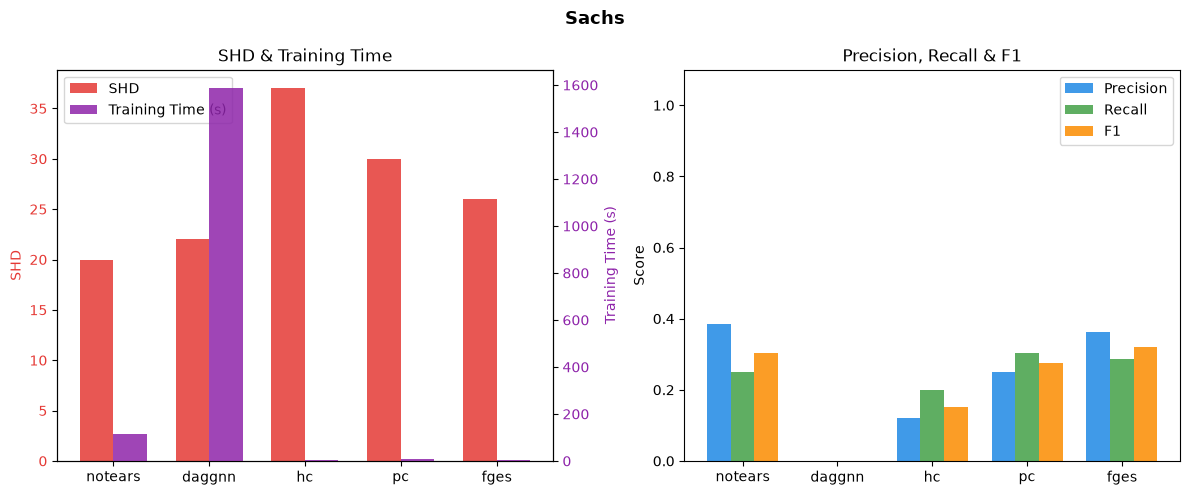

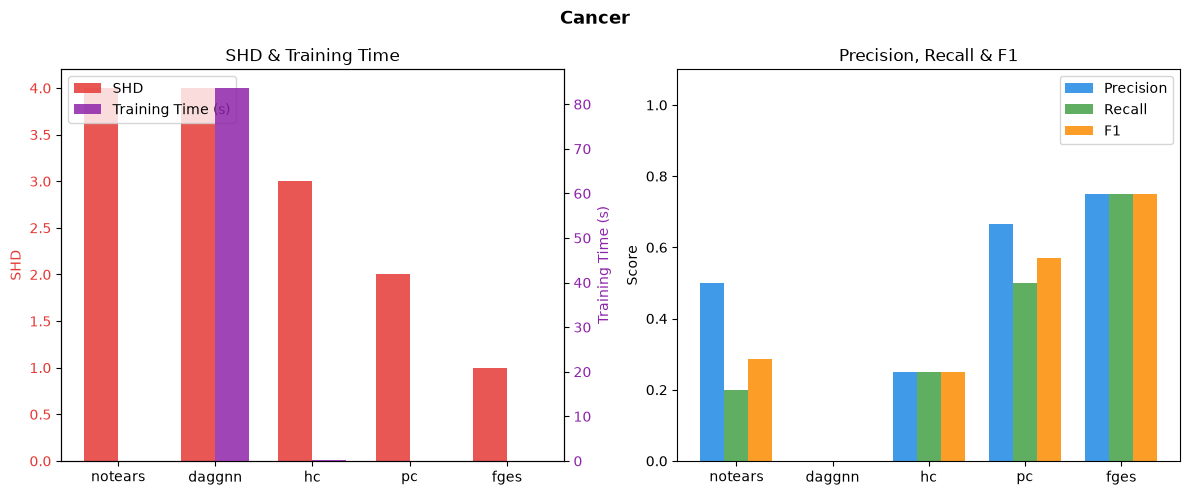

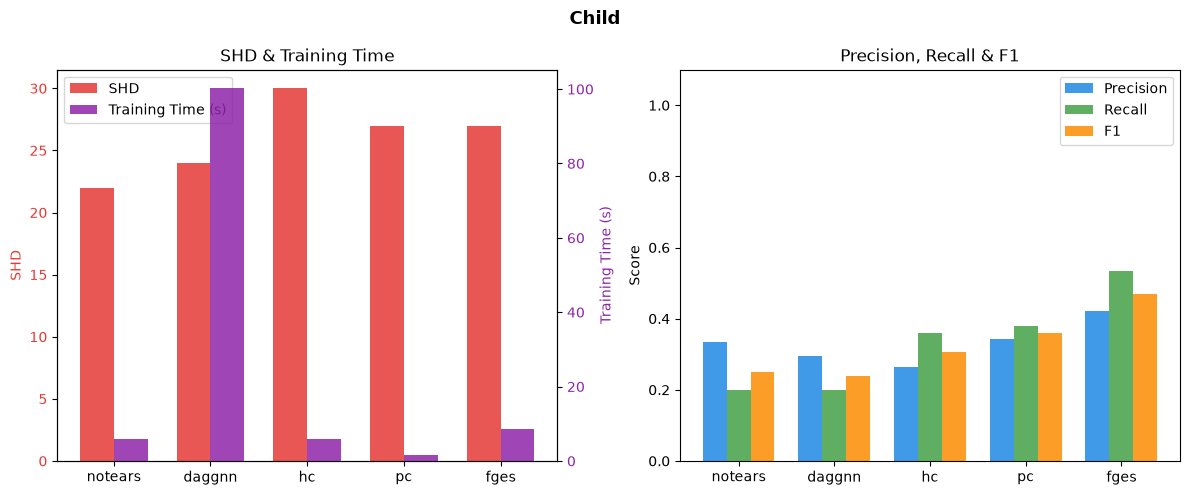

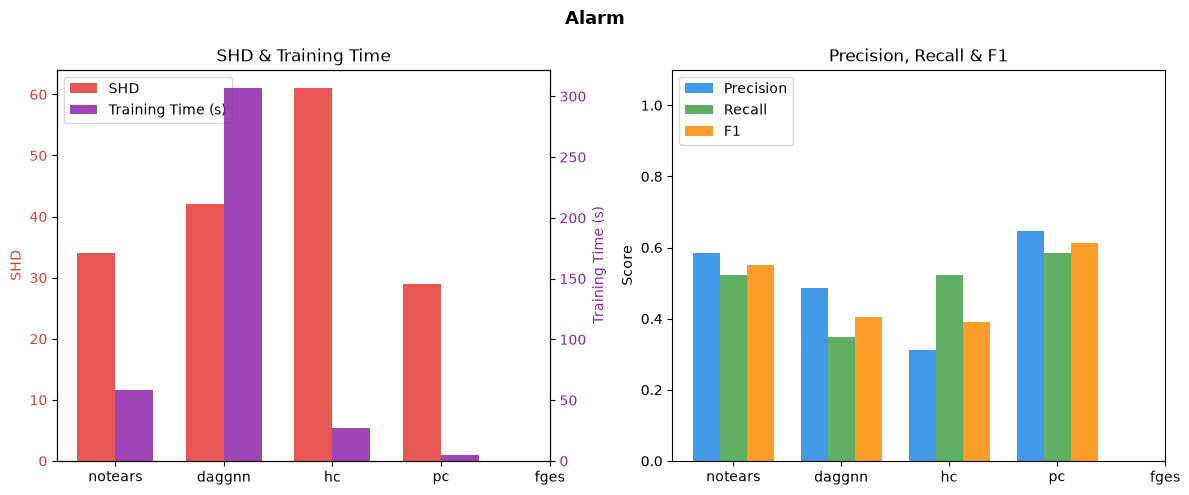

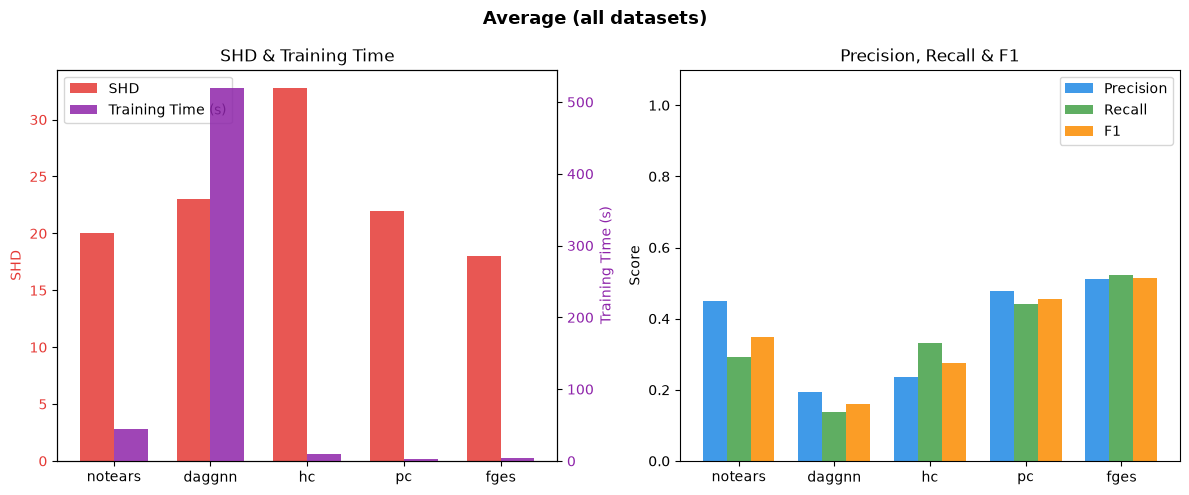

In [6]:
datasets = {
    "Sachs": {
        "notears": (sachs_notears_metrics,  sachs_notears_result.elapsed_s),
        "daggnn":  (sachs_daggnn_metrics,   sachs_daggnn_result.elapsed_s),
        "hc":      (sachs_hc_metrics,       sachs_hc_result.elapsed_s),
        "pc":      (sachs_pc_metrics,       sachs_pc_result.elapsed_s),
        "fges":    (sachs_fges_metrics,     sachs_fges_result.elapsed_s),
    },
    "Cancer": {
        "notears": (cancer_notears_metrics, cancer_notears_result.elapsed_s),
        "daggnn":  (cancer_daggnn_metrics,  cancer_daggnn_result.elapsed_s),
        "hc":      (cancer_hc_metrics,      cancer_hc_result.elapsed_s),
        "pc":      (cancer_pc_metrics,      cancer_pc_result.elapsed_s),
        "fges":    (cancer_fges_metrics,    cancer_fges_result.elapsed_s),
    },
    "Child": {
        "notears": (child_notears_metrics,  child_notears_result.elapsed_s),
        "daggnn":  (child_daggnn_metrics,   child_daggnn_result.elapsed_s),
        "hc":      (child_hc_metrics,       child_hc_result.elapsed_s),
        "pc":      (child_pc_metrics,       child_pc_result.elapsed_s),
        "fges":    (child_fges_metrics,     child_fges_result.elapsed_s),
    },
    "Alarm": {
        "notears": (alarm_notears_metrics,  alarm_notears_result.elapsed_s),
        "daggnn":  (alarm_daggnn_metrics,   alarm_daggnn_result.elapsed_s),
        "hc":      (alarm_hc_metrics,       alarm_hc_result.elapsed_s),
        "pc":      (alarm_pc_metrics,       alarm_pc_result.elapsed_s),
        # fges: does not terminate on 37-node datasets
    },
}

ALGORITHMS  = ["notears", "daggnn", "hc", "pc", "fges"]
SHD_COLOR   = "#E53935"
TIME_COLOR  = "#8E24AA"
PRF_COLORS  = {"precision": "#1E88E5", "recall": "#43A047", "f1": "#FB8C00"}


def _plot_dataset(title, algo_data):
    fig, (ax_shd_time, ax_prf) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    x = np.arange(len(ALGORITHMS))
    w = 0.35

    # left: SHD (left axis) + training time (right axis)
    ax_time = ax_shd_time.twinx()

    shd_vals  = [algo_data[a][0]["shd"] if a in algo_data else float("nan") for a in ALGORITHMS]
    time_vals = [algo_data[a][1]        if a in algo_data else float("nan") for a in ALGORITHMS]

    b_shd  = ax_shd_time.bar(x - w / 2, shd_vals,  w, color=SHD_COLOR,  alpha=0.85, label="SHD")
    b_time = ax_time.bar(    x + w / 2, time_vals, w, color=TIME_COLOR, alpha=0.85, label="Training Time (s)")

    ax_shd_time.set_xticks(x)
    ax_shd_time.set_xticklabels(ALGORITHMS)
    ax_shd_time.set_ylabel("SHD",              color=SHD_COLOR)
    ax_shd_time.tick_params(axis="y",           labelcolor=SHD_COLOR)
    ax_time.set_ylabel("Training Time (s)",     color=TIME_COLOR)
    ax_time.tick_params(axis="y",               labelcolor=TIME_COLOR)
    ax_shd_time.set_title("SHD & Training Time")
    ax_shd_time.legend(handles=[b_shd, b_time], loc="upper left")

    # right: precision, recall, F1
    w3 = 0.25
    offsets = [-w3, 0, w3]
    for (metric, color), offset in zip(PRF_COLORS.items(), offsets):
        vals = [algo_data[a][0][metric] if a in algo_data else float("nan") for a in ALGORITHMS]
        ax_prf.bar(x + offset, vals, w3, color=color, alpha=0.85, label=metric.capitalize())

    ax_prf.set_xticks(x)
    ax_prf.set_xticklabels(ALGORITHMS)
    ax_prf.set_ylabel("Score")
    ax_prf.set_ylim(0, 1.1)
    ax_prf.set_title("Precision, Recall & F1")
    ax_prf.legend()

    fig.tight_layout()
    plt.show()


for name, algo_data in datasets.items():
    _plot_dataset(name, algo_data)

# aggregate figure — average only over datasets where the algorithm was run
avg_data = {
    algo: (
        {m: np.mean([datasets[ds][algo][0][m] for ds in datasets if algo in datasets[ds]])
         for m in ["shd", "precision", "recall", "f1"]},
        np.mean([datasets[ds][algo][1] for ds in datasets if algo in datasets[ds]]),
    )
    for algo in ALGORITHMS
}
_plot_dataset("Average (all datasets)", avg_data)


KeyError: 'fges'

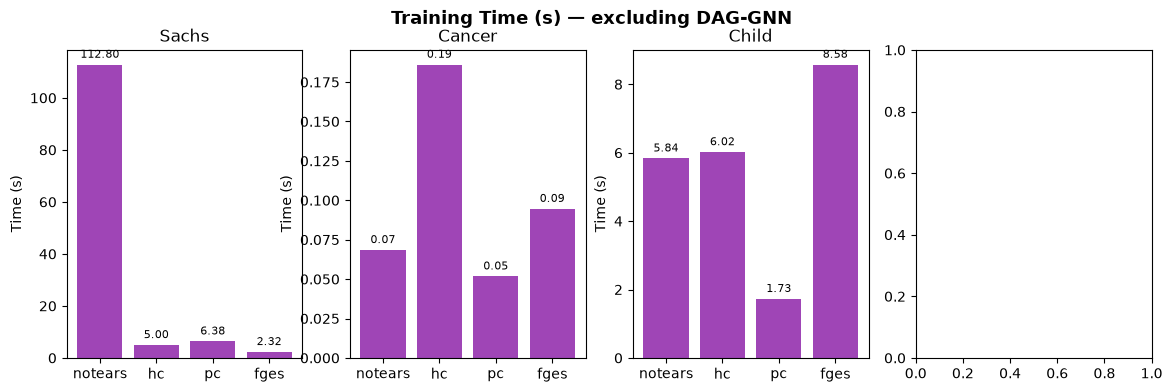

In [7]:
ALGOS_NO_DAGGNN = [a for a in ALGORITHMS if a != "daggnn"]

fig, axes = plt.subplots(1, len(datasets), figsize=(14, 4), sharey=False)
fig.suptitle("Training Time (s) — excluding DAG-GNN", fontsize=13, fontweight="bold")

for ax, (ds_name, algo_data) in zip(axes, datasets.items()):
    x = np.arange(len(ALGOS_NO_DAGGNN))
    times = [algo_data[a][1] for a in ALGOS_NO_DAGGNN]
    bars = ax.bar(x, times, color=TIME_COLOR, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(ALGOS_NO_DAGGNN)
    ax.set_title(ds_name)
    ax.set_ylabel("Time (s)")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

fig.tight_layout()
plt.show()


In [8]:
import pandas as pd

def _accuracy(m):
    denom = m["tp"] + m["fp"] + m["fn"] + m["reversed"]
    return m["tp"] / denom if denom > 0 else 0.0

rows = []

for ds_name, algo_data in datasets.items():
    for algo in ALGORITHMS:
        if algo not in algo_data:
            continue
        m, elapsed = algo_data[algo]
        rows.append({
            "Dataset":   ds_name,
            "Algorithm": algo.upper(),
            "Time (s)":  round(elapsed, 2),
            "SHD":       m["shd"],
            "Accuracy":  round(_accuracy(m), 3),
            "Precision": round(m["precision"], 3),
            "Recall":    round(m["recall"], 3),
            "F1":        round(m["f1"], 3),
        })

for algo in ALGORITHMS:
    present = [ds for ds in datasets if algo in datasets[ds]]
    if not present:
        continue
    ms = [datasets[ds][algo][0] for ds in present]
    rows.append({
        "Dataset":   "Average",
        "Algorithm": algo.upper(),
        "Time (s)":  round(np.mean([datasets[ds][algo][1] for ds in present]), 2),
        "SHD":       round(np.mean([m["shd"] for m in ms]), 1),
        "Accuracy":  round(np.mean([_accuracy(m) for m in ms]), 3),
        "Precision": round(np.mean([m["precision"] for m in ms]), 3),
        "Recall":    round(np.mean([m["recall"] for m in ms]), 3),
        "F1":        round(np.mean([m["f1"] for m in ms]), 3),
    })

summary_df = pd.DataFrame(rows).set_index(["Dataset", "Algorithm"])
summary_df


Time (s)   SHD  Accuracy  Precision  Recall     F1
Dataset Algorithm                                                    
Sachs   NOTEARS      112.80  20.0     0.200      0.385   0.250  0.303
        DAGGNN      1585.98  22.0     0.000      0.000   0.000  0.000
        HC             5.00  37.0     0.098      0.121   0.200  0.151
        PC             6.38  30.0     0.189      0.250   0.304  0.275
        FGES           2.32  26.0     0.235      0.364   0.286  0.320
Cancer  NOTEARS        0.07   4.0     0.200      0.500   0.200  0.286
        DAGGNN        83.63   4.0     0.000      0.000   0.000  0.000
        HC             0.19   3.0     0.250      0.250   0.250  0.250
        PC             0.05   2.0     0.500      0.667   0.500  0.571
        FGES           0.09   1.0     0.750      0.750   0.750  0.750
Child   NOTEARS        5.84  22.0     0.185      0.333   0.200  0.250
        DAGGNN       100.21  24.0     0.172      0.294   0.200  0.238
        HC             6.02  30.0     0.231      0.265   0.360  0.305
        PC             1.73  27.0     0.289      0.344   0.379  0.361
        FGES           8.58  27.0     0.372      0.421   0.533  0.471
Alarm   NOTEARS       58.17  34.0     0.414      0.585   0.522  0.552
        DAGGNN       306.54  42.0     0.276      0.485   0.348  0.405
        HC            27.28  61.0     0.282      0.312   0.522  0.390
        PC             4.50  29.0     0.517      0.646   0.585  0.614
Average NOTEARS       44.22  20.0     0.250      0.451   0.293  0.348
        DAGGNN       519.09  23.0     0.112      0.195   0.137  0.161
        HC             9.62  32.8     0.215      0.237   0.333  0.274
        PC             3.16  22.0     0.374      0.477   0.442  0.455
        FGES           3.66  18.0     0.452      0.512   0.523  0.514